# Phase 7: what does combining similar models buy?

The top public notebooks reach 0.941 with about 40 models from four families; our single CoAtNet scores 0.927.
Before asking how much comes from *different* families, this notebook measures what the *same* family buys:
the author's three public CoAtNet checkpoints, and the extra "flipped" view the public ensemble adds.

| Arm | Checkpoint | Image size | Slices | Slice range | Windows |
|---|---|---|---|---|---|
| v5 (maxspan) | `raptor_ft_coatnet_v5_full_swa.pt` | 336, upscaled to 384 | 64 | 2-98% | 62 |
| v10 (ours) | `raptor_ft_coatnet_v10_full.pt` | 384 | 64 | 2-98% | 62 |
| v8 (native 384) | `raptor_ft_coatnet_v8_full_swa.pt` | 384 | 44 | 6-94% | 42 |

The "flipped" view reverses the three slices inside every window (c+1, c, c-1). It does not reverse the order of
the windows: Phase 4 showed the head cannot see window order, so that would change nothing.

A Kaggle job (`kaggle/arms_gold`) encoded the 58 gold studies with each checkpoint, in both channel orders, and saved
each checkpoint's head. Everything below runs on a laptop.

In [1]:
import itertools
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import evaluation as ev
import plot_style as ps
import raptor_core as rc

ps.apply()
A = ROOT / "outputs/kaggle/arms_gold"
FIG = ROOT / "outputs/figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 4)

gold = pd.read_csv(A / "gold_labels.csv")
Y = gold[rc.LAB].values.astype(int)
ARMS = ["v5", "v10", "v8"]


def head(name):
    h = rc.RaptorClassifier(torch.nn.Identity(), F_dim=1024)
    h.load_state_dict(torch.load(A / f"head_{name}.pt"))
    return h.eval()


def logits(name, flip=False, k=None):
    feats = np.load(A / f"feats_{name}_{'flip' if flip else 'normal'}.npy").astype(np.float32)
    if k:                                          # a window subset: centres of the full stack's eval_centers
        idx = [c - 1 for c in rc.eval_centers(np.ones(feats.shape[1] + 2, np.uint8), k)]
        feats = feats[:, idx]
    with torch.no_grad():
        return head(name).head(torch.from_numpy(feats)).numpy().astype(np.float64)


def wrong_pairs(P):
    return np.array([(1 - ev.psi(P[Y[:, j] == 1, j], P[Y[:, j] == 0, j])).sum() for j in range(len(rc.LAB))])

## 1. Are all three checkpoints reproduced?

Phase 0's fingerprint, per checkpoint: the stored per-finding AUCs fix how many positive-negative pairs each
checkpoint ranked wrongly, and our pipeline should give the same counts.

In [2]:
rows = []
for name in ARMS:
    meta = json.load(open(A / f"meta_{name}.json"))
    stored = np.array([Y[:, j].sum() * (len(Y) - Y[:, j].sum()) * (1 - meta["aucs"][l]) for j, l in enumerate(rc.LAB)])
    for k in (None, 24):
        L = logits(name, k=k)
        rows.append({"checkpoint": name, "windows": k or "all", "stored macro-AUC": meta["gold_auc"],
                     "our macro-AUC": rc.macro_auc(Y, L)[0], "pairs from stored fingerprint": np.abs(wrong_pairs(L) - stored).sum()})
pd.DataFrame(rows).set_index(["checkpoint", "windows"])

stored macro-AUC  our macro-AUC  \
checkpoint windows                                    
v5         all                0.9214         0.9199   
           24                 0.9214         0.9212   
v10        all                0.9174         0.9169   
           24                 0.9174         0.9181   
v8         all                0.9067         0.9116   
           24                 0.9067         0.9068   

                    pairs from stored fingerprint  
checkpoint windows                                 
v5         all                               61.0  
           24                                 2.0  
v10        all                               69.0  
           24                                 6.0  
v8         all                               62.0  
           24                                 5.0

At 24 windows every checkpoint lands within 2-6 ranked pairs of its stored numbers, including v5's 336 px layout
and v8's 44-slice one. The pipeline reproduces all three, and all three stored scores came from 24 windows.

v5 and v8 are averages of their three best epochs (SWA), picked by their score on these same 58 studies, so their
gold numbers carry the selection optimism Phase 2 measured. The leaderboard is the real test.

## 2. Singles, flips and ensembles

Ensembles average the arms' probabilities, as the public notebooks do. The public weights (0.6 v5, 0.1 v5 flipped,
0.1 v10, 0.2 v8) were fixed in advance as the one candidate for the leaderboard, so no choice here is made on these
58 studies.

In [3]:
sig = lambda x: 1 / (1 + np.exp(-x))
views = {f"{n}{'-flip' if f else ''}": sig(logits(n, f)) for n in ARMS for f in (False, True)}


def blend(weights):
    return sum(views[k] * w for k, w in weights.items()) / sum(weights.values())


models = {
    "v10 (ours)": views["v10"], "v5": views["v5"], "v8": views["v8"],
    "v10 + its flipped view": blend({"v10": 1, "v10-flip": 1}),
    "v5 + its flipped view": blend({"v5": 1, "v5-flip": 1}),
    "3 checkpoints, equal": blend({"v5": 1, "v10": 1, "v8": 1}),
    "public weights (pre-registered)": blend({"v5": .6, "v5-flip": .1, "v10": .1, "v8": .2}),
    "all 6 views, equal": blend({k: 1 for k in views}),
}
W = ev.bootstrap_weights(len(Y), 4000, seed=2646)
ref = np.nanmean(ev.bootstrap_aucs(Y, models["v10 (ours)"], W), axis=1)
rows = []
for name, P in models.items():
    d = np.nanmean(ev.bootstrap_aucs(Y, P, W), axis=1) - ref
    lo, hi = ev.percentile_ci(d)
    rows.append({"model": name, "macro-AUC": rc.macro_auc(Y, P)[0], "change vs v10": rc.macro_auc(Y, P)[0] - rc.macro_auc(Y, models["v10 (ours)"])[0],
                 "95% paired CI": f"{lo:+.3f} to {hi:+.3f}", "better in % of resamples": (d > 0).mean() * 100})
table = pd.DataFrame(rows).set_index("model")
table

,macro-AUC,change vs v10,95% paired CI,better in % of resamples
model,,,,
v10 (ours),0.9169,0.0000,+0.000 to +0.000,0.000
v5,0.9199,0.0031,-0.009 to +0.015,70.450
v8,0.9116,-0.0052,-0.019 to +0.009,23.150
v10 + its flipped view,0.9161,-0.0007,-0.005 to +0.003,37.500
v5 + its flipped view,0.9185,0.0016,-0.011 to +0.014,61.125
"3 checkpoints, equal",0.9249,0.0080,+0.001 to +0.016,98.925
public weights (pre-registered),0.9258,0.0089,-0.001 to +0.019,96.725
"all 6 views, equal",0.9239,0.0070,-0.002 to +0.016,94.525


- **The flipped view adds nothing.** v10 with its flipped view scores 0.916 against 0.917 alone, and v5 likewise.
- **Different checkpoints add about +0.008.** The three checkpoints averaged equally score 0.925, better than v10
  alone in 99% of paired resamples, with an interval of +0.001 to +0.016. It is the first gain in this project that
  clears a paired test on the 58 studies.
- **The public weights do about the same** (0.926); their interval just touches zero.

## 3. Why: diversity

Averaging two models can only help where their errors differ. Measure how alike two views are by the correlation of
their scores across studies (averaged over the 12 findings), and set it against what averaging the pair gains over
the mean of the two alone, for all 15 pairs of the six views.

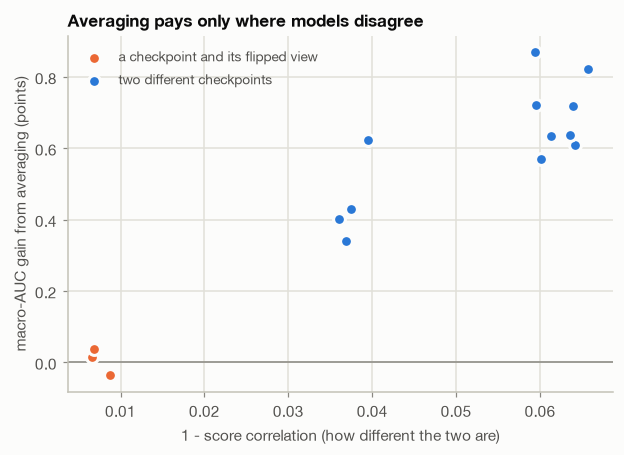

,pair,correlation,gain over the two alone,same checkpoint
0,v5 / v5-flip,0.9933,0.0001,True
9,v10 / v10-flip,0.9931,0.0004,True
14,v8 / v8-flip,0.9912,-0.0004,True
6,v5-flip / v10-flip,0.9640,0.0040,False
1,v5 / v10,0.9632,0.0034,False
2,v5 / v10-flip,0.9625,0.0043,False
5,v5-flip / v10,0.9605,0.0062,False
3,v5 / v8,0.9406,0.0087,False
10,v10 / v8,0.9405,0.0072,False
7,v5-flip / v8,0.9399,0.0057,False


In [4]:
def mean_corr(a, b):
    la, lb = np.log(views[a] / (1 - views[a])), np.log(views[b] / (1 - views[b]))
    return np.mean([np.corrcoef(la[:, j], lb[:, j])[0, 1] for j in range(len(rc.LAB))])


pairs = []
for a, b in itertools.combinations(views, 2):
    single = (rc.macro_auc(Y, views[a])[0] + rc.macro_auc(Y, views[b])[0]) / 2
    pairs.append({"pair": f"{a} / {b}", "correlation": mean_corr(a, b),
                  "gain over the two alone": rc.macro_auc(Y, (views[a] + views[b]) / 2)[0] - single,
                  "same checkpoint": a.split("-")[0] == b.split("-")[0]})
pairs = pd.DataFrame(pairs)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
for same, colour, label in [(True, ps.ORANGE, "a checkpoint and its flipped view"), (False, ps.BLUE, "two different checkpoints")]:
    sub = pairs[pairs["same checkpoint"] == same]
    ax.scatter(1 - sub.correlation, sub["gain over the two alone"] * 100, s=60, color=colour,
               edgecolor=ps.SURFACE, linewidth=2, label=label, zorder=3)
ax.axhline(0, color=ps.MUTED, lw=1)
ax.set_xlabel("1 - score correlation (how different the two are)")
ax.set_ylabel("macro-AUC gain from averaging (points)")
ax.set_title("Averaging pays only where models disagree")
ax.legend(loc="upper left", fontsize=9)
fig.savefig(FIG / "phase7_diversity.png")
plt.show()
pairs.sort_values("correlation", ascending=False).round(4)

A checkpoint and its flipped view correlate at 0.993: averaging them is averaging a model with itself, and it gains
nothing. Two different checkpoints correlate at 0.94-0.96 and gain 0.3-0.9 points, the most for pairs with v8, the
least similar checkpoint (0.94). The author trained them on
different slice layouts, image sizes and spans, so they make slightly different mistakes, and only those differences
cancel.

The public ensemble's jump from 0.927 to 0.941 fits the same rule: its big gains come from DINOv2, DINOv3 and
RadImageNet models, which are far less correlated with a CoAtNet than another CoAtNet is.

## 4. Where it helps

In [5]:
per = pd.DataFrame({name: rc.macro_auc(Y, P)[1] for name, P in
                    [("v10 (ours)", models["v10 (ours)"]), ("public weights", models["public weights (pre-registered)"])]})
per["change"] = per["public weights"] - per["v10 (ours)"]
per.sort_values("change", ascending=False)

,v10 (ours),public weights,change
Lateral Meniscus,0.8497,0.8795,0.0298
MCL,0.9592,0.9864,0.0272
Fracture,0.9000,0.9236,0.0236
PF OA,0.8301,0.8468,0.0167
Medial OA,0.9628,0.9783,0.0155
Effusion,0.9714,0.9826,0.0112
Synovitis,0.8041,0.8112,0.0072
Contusion,0.9420,0.9474,0.0054
ACL,0.9755,0.9755,0.0000
Medial Meniscus,0.9663,0.9663,0.0000


The gains land on findings where v10 was weakest or most uncertain: lateral meniscus (+0.030), MCL (+0.027),
fracture (+0.024). Two findings get worse (Baker's cyst -0.013, lateral OA -0.017). Per finding, each of these moves
is well inside the ±0.05-0.12 uncertainty of a single finding on 58 studies; only the macro average is resolved.

## 5. The hidden test set

The pre-registered ensemble (public weights) was submitted once through `kaggle/submit` with `VARIANT=RAPTOR4`.

| Model | 58 labelled studies | Public leaderboard | Rank of 4,008 teams |
|---|---|---|---|
| v10 alone | 0.917 | 0.927 | about 1,673 |
| Four-arm ensemble | 0.926 | **0.932** | about 1,575 |
| Gain | +0.009 | **+0.005** | |

- **About half the gold-set gain survives.** The other half is the expected loss: v5 and v8 are averages of epochs
  chosen on these same 58 studies, so part of their advantage there was selection, as Phase 2 predicted.
- **The rest is real.** Averaging three similar checkpoints, with no training at all, adds +0.005 on unseen data.
- **It explains about a third of the public stack's lead.** From 0.927 the public stack reaches 0.941 (+0.014);
  same-family averaging gives +0.005 of that. The remaining +0.009 comes from model families that disagree more with
  a CoAtNet, which is what the diversity figure predicts.

The four-arm run costs about 6.5 s per study on a T4, three times the single model, and scoring the hidden test set
took about 4.4 hours of the 9-hour limit.

## 6. Summary

| Question | Answer |
|---|---|
| Are the other public checkpoints reproduced? | Yes: v5 and v8 within 2-5 ranked pairs of their stored scores |
| Does the public "flipped" view help? | No: it correlates 0.993 with the unflipped model and gains nothing |
| Do different checkpoints help? | Yes: +0.008 on gold (paired CI +0.001 to +0.016), +0.005 on the hidden test |
| What predicts the gain? | How much two models disagree: 0.3-0.9 points for correlations of 0.96-0.94, none at 0.99 |
| How much of the public stack's lead does this explain? | About a third (+0.005 of +0.014) |